In [218]:
from HeaderP import *
from astropy.table import Table 
import apogee_drp
import urllib
import os
from astropy.table import QTable

def Table_to_pandas(fn, input_id=1):
    data = fits.open(fn)
    boss_mwm = QTable(data[input_id].data)
    cols = []
    cols_drop = []
    for i in boss_mwm.columns:
        #print(boss_mwm[i][0])
        if np.size(boss_mwm[i][0])==1:
            cols.append(i)
        else:
            cols_drop.append(i)
    print(cols_drop)
    return boss_mwm[cols].to_pandas()

def movingMed_time(x,y,x_window,delta_x_window,minn_points=5,std_calc=False):
    x, y = zip(*sorted(zip(x,y)))
    x, y = np.array(x), np.array(y)
    # medians output
    x_med=np.ones(len(x))*np.nan
    y_med=np.ones(len(y))*np.nan
    if std_calc:
        y_std = np.ones(len(x))*np.nan
    # define the boundaries of the windows
    if len(x)==0:
        return x_med,y_med
    window_min=float(min(x))
    window_max=float(window_min+delta_x_window)
    
    # max time
    maxtime=max(x)
    #print(window_min, maxtime)
    
    # break when time window hits the end
    while window_max<=maxtime+x_window:
        seldf=(x>=window_min) & (x<=window_max) # get points between the window
        
        if sum(seldf)<minn_points:
            x_med[seldf]=np.nan
            y_med[seldf]=np.nan
            

        else:
            x_med[seldf]=np.nanmedian(x[seldf]) # all values for these indices are subsituded with median time
            y_med[seldf]=np.nanmedian(y[seldf]) # all values for these indices are subsituded with median flux
            if std_calc:
                y_std[seldf]=np.nanmedian(abs(y[seldf]-np.median(y[seldf])))
            
        # slide the window
        window_min=window_min+delta_x_window
        window_max=window_max+delta_x_window
    if std_calc:
        return x_med[y_med==y_med], y_med[y_med==y_med], y_std[y_med==y_med]
    else:
        return x_med[y_med==y_med], y_med[y_med==y_med]



In [2]:
# path to a list of exposures: $APOGEE_DATA_S, and $APOGEE_DATA_N

In [7]:
folder_name = '/uufs/chpc.utah.edu/common/home/sdss51/sdsswork/mwm/apogee/spectro/redux/ipl-4/summary/'


In [8]:
fnames = os.listdir(folder_name)
fnames

['allVisit-1.5-apo25m.fits',
 'allVisit-1.5-lco25m.fits',
 'allStar-1.5-apo25m.fits',
 'allStar-1.5-lco25m.fits']

In [9]:
# Check each files

Checking  /uufs/chpc.utah.edu/common/home/sdss51/sdsswork/mwm/apogee/spectro/redux/ipl-4/summary/allVisit-1.5-apo25m.fits
['rv_components']


 ################## check version and missing data ##################
DRP version,  ['1.5']
3/2051477 stars have no mjd
3022/2051474 stars have no G mag
501/1998807 stars have no SNR
1056313/1985390 (0.53) stars have flags!


 ################## check flags ##################
BAD_PIXELS 10463/1985390 (0.01) stars
COMMISSIONING 0/1985390 (0.00) stars
BRIGHT_NEIGHBOR 150201/1985390 (0.08) stars
VERY_BRIGHT_NEIGHBOR 7804/1985390 (0.00) stars
LOW_SNR 26162/1985390 (0.01) stars
PERSIST_HIGH 0/1985390 (0.00) stars
PERSIST_MED 32674/1985390 (0.02) stars
PERSIST_LOW 257080/1985390 (0.13) stars
PERSIST_JUMP_POS 11363/1985390 (0.01) stars
PERSIST_JUMP_NEG 10704/1985390 (0.01) stars
SUSPECT_RV_COMBINATION 0/1985390 (0.00) stars
SUSPECT_BROAD_LINES 0/1985390 (0.00) stars


 ################## check SNR as a function of gaia mag ##################


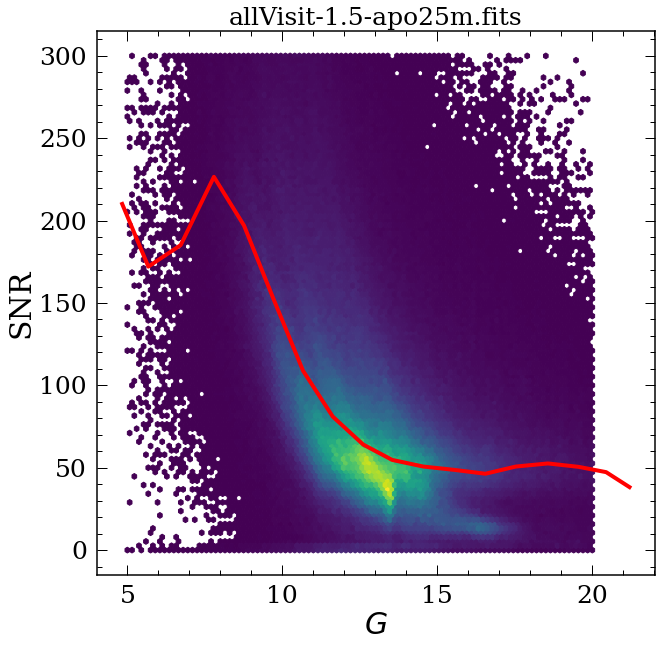



 ################## check SNR as a function of MJD ##################


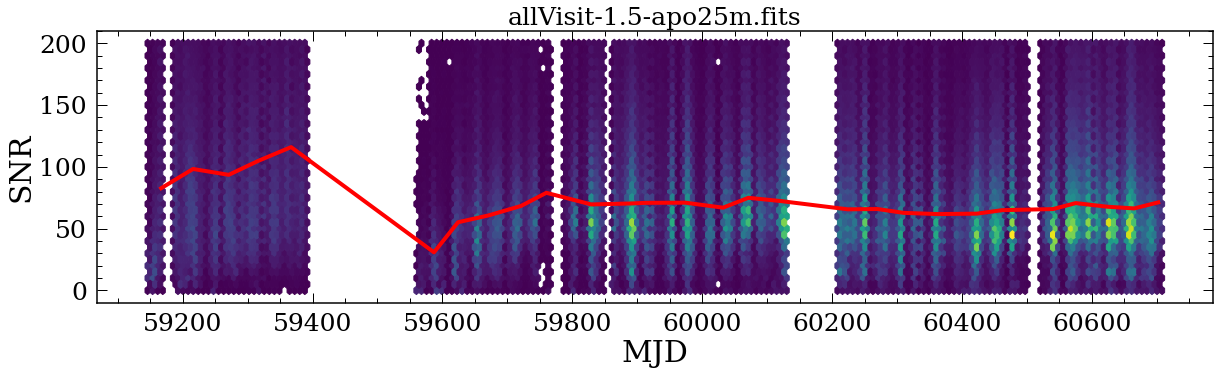



 ################## check rvs for each star ##################
Unique Stars:  958749
[]
Unique stars from visits: 958749
Unique stars from allstars: 961715


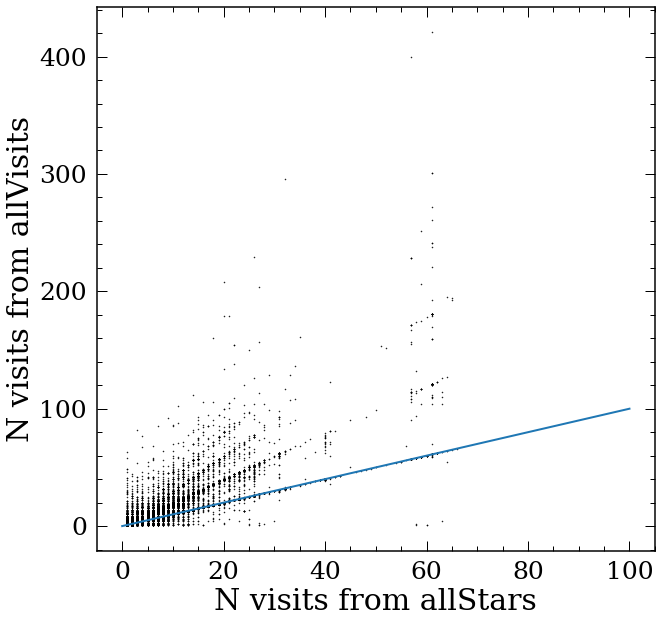

Checking  /uufs/chpc.utah.edu/common/home/sdss51/sdsswork/mwm/apogee/spectro/redux/ipl-4/summary/allVisit-1.5-lco25m.fits
['rv_components']


 ################## check version and missing data ##################
DRP version,  ['1.5']
0/1390382 stars have no mjd
4803/1390382 stars have no G mag
822/1350784 stars have no SNR
694906/1349928 (0.51) stars have flags!


 ################## check flags ##################
BAD_PIXELS 2819/1349928 (0.00) stars
COMMISSIONING 0/1349928 (0.00) stars
BRIGHT_NEIGHBOR 73967/1349928 (0.05) stars
VERY_BRIGHT_NEIGHBOR 2781/1349928 (0.00) stars
LOW_SNR 19139/1349928 (0.01) stars
PERSIST_HIGH 0/1349928 (0.00) stars
PERSIST_MED 0/1349928 (0.00) stars
PERSIST_LOW 0/1349928 (0.00) stars
PERSIST_JUMP_POS 3995/1349928 (0.00) stars
PERSIST_JUMP_NEG 8799/1349928 (0.01) stars
SUSPECT_RV_COMBINATION 0/1349928 (0.00) stars
SUSPECT_BROAD_LINES 0/1349928 (0.00) stars


 ################## check SNR as a function of gaia mag ##################


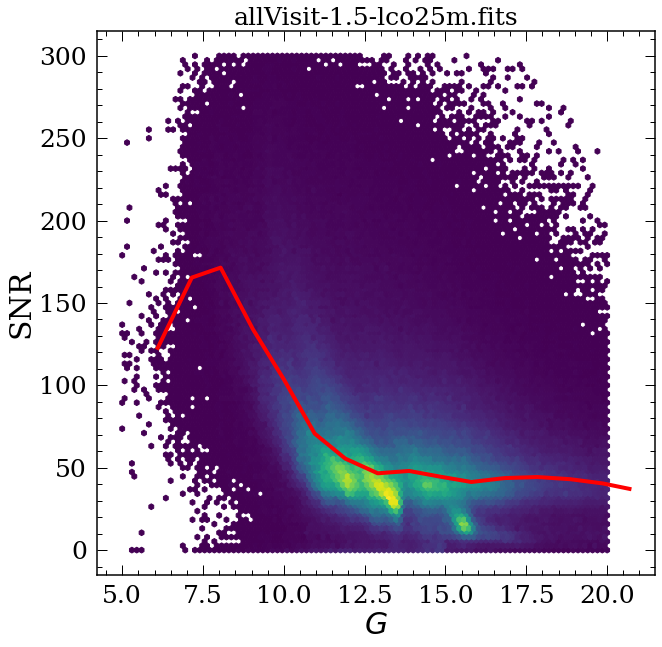



 ################## check SNR as a function of MJD ##################


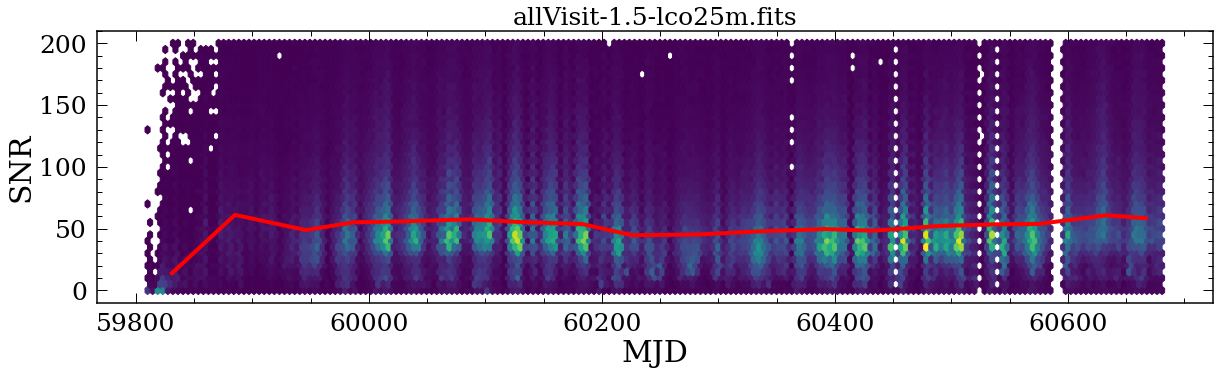



 ################## check rvs for each star ##################
Unique Stars:  746649
[]
Unique stars from visits: 746649
Unique stars from allstars: 740902


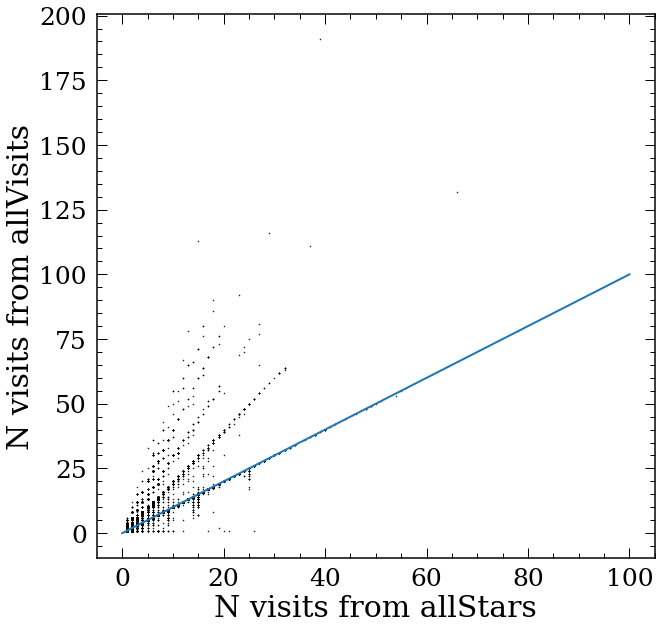

In [220]:
import warnings
warnings.filterwarnings('ignore') 

for iii in range(len(fnames)):
    if 'allVisit' in fnames[iii]:
        print('Checking ', folder_name+fnames[iii])
        df = Table_to_pandas(folder_name+fnames[iii])

        print('\n\n ################## check version and missing data ##################')

        print('DRP version, ', df['apred_vers'].unique())
        print('%d/%d stars have no mjd'%(sum(df['mjd']<0), len(df)))
        df = df[df['mjd']>0].reset_index(drop=True)
        print('%d/%d stars have no G mag'%(sum(df['gaia_gmag']<0), len(df)))
        df = df[df['gaia_gmag']>0].reset_index(drop=True)
        print('%d/%d stars have no SNR'%(sum(df['snr']<0), len(df)))
        df = df[df['snr']>0].reset_index(drop=True)
        print('%d/%d (%.2f) stars have flags!'%(sum(df['starflag']!=0), len(df), sum(df['starflag']!=0)/len(df)))


        print('\n\n ################## check flags ##################')
        """
        BAD_PIXELS	0	Spectrum has many bad pixels (>40%): BAD
        COMMISSIONING	1	Commissioning data (MJD<55761), non-standard configuration, poor LSF: WARN
        BRIGHT_NEIGHBOR	2	Star has neighbor more than 10 times brighter: WARN
        VERY_BRIGHT_NEIGHBOR	3	Star has neighbor more than 100 times brighter: BAD
        LOW_SNR	4	Spectrum has low S/N (S/N<5): BAD
        PERSIST_HIGH	9	Spectrum has significant number (>20%) of pixels in high persistence region: WARN
        PERSIST_MED	10	Spectrum has significant number (>20%) of pixels in medium persistence region: WARN
        PERSIST_LOW	11	Spectrum has significant number (>20%) of pixels in low persistence region: WARN
        PERSIST_JUMP_POS	12	Spectrum show obvious positive jump in blue chip: WARN
        PERSIST_JUMP_NEG	13	Spectrum show obvious negative jump in blue chip: WARN
        SUSPECT_RV_COMBINATION	16	WARNING: RVs from synthetic template differ significantly from those from combined template
        SUSPECT_BROAD_LINES	17
        """
        flags = {
        0:'BAD_PIXELS',
        1:'COMMISSIONING',
        2:'BRIGHT_NEIGHBOR',
        3:'VERY_BRIGHT_NEIGHBOR',
        4:'LOW_SNR',
        9:'PERSIST_HIGH',
        10:'PERSIST_MED',
        11:'PERSIST_LOW',
        12:'PERSIST_JUMP_POS',
        13:'PERSIST_JUMP_NEG',
        16:'SUSPECT_RV_COMBINATION',
        17:'SUSPECT_BROAD_LINES'
        }

        flagnumbs = np.zeros(len(flags))

        for i, bit in enumerate(flags.keys()):

            # check which rows have this bit set
            mask = (df['starflag'] & (1 << bit)) != 0

            flagnumbs[i] = mask.sum()

        for i, name in enumerate(flags.values()):
            print(name, "%d/%d (%.2f) stars"%(flagnumbs[i], len(df), flagnumbs[i]/len(df)))


        print('\n\n ################## check SNR as a function of gaia mag ##################')
        plt.figure()
        plt.hexbin(df['gaia_gmag'], df['snr'], extent=(5, 20, 0, 300), mincnt=1)
        x, y = movingMed_time(df['gaia_gmag'], df['snr'], 1, 1, minn_points=50)
        plt.plot(x, y, 'r-', linewidth=4)
        plt.xlabel('$G$')
        plt.ylabel('SNR')
        plt.title(fnames[iii], fontsize=25)
        plt.show()

        print('\n\n ################## check SNR as a function of MJD ##################')
        plt.figure(figsize=(20,5))
        plt.hexbin(df['mjd'], df['snr'], mincnt=1, gridsize=(200, 20), extent=(min(df['mjd']), max(df['mjd']), 0, 200))
        x, y = movingMed_time(df['mjd'], df['snr'], 50, 50, minn_points=50)
        plt.plot(x, y, 'r-', linewidth=4)
        plt.xlabel('MJD')
        plt.ylabel('SNR')
        plt.title(fnames[iii], fontsize=25)
        plt.show()
        
        
        print('\n\n ################## check rvs for each star ##################')
        # calculate N visits
        df_good = df.loc[df['sdss_id']>0].reset_index(drop=True)
        visits = df_good.groupby('sdss_id').size().reset_index(name='Nvisit')
        print('Unique Stars: ', len(visits))
        
        if iii==0:
            df_allstars = Table_to_pandas(folder_name+fnames[2])
        if iii==1:
            df_allstars = Table_to_pandas(folder_name+fnames[3])
        
        allstars_sdss_unique = df_allstars['sdss_id'].unique()
        print('Unique stars from visits: %d'%(len(visits)))
        print('Unique stars from allstars: %d'%(len(allstars_sdss_unique)))
        
        
        sdss_star_visit = pd.merge(visits, df_allstars[['sdss_id','nvisits']])
        
        plt.plot(sdss_star_visit['nvisits'], sdss_star_visit['Nvisit'], 'k.', ms=1)
        plt.xlabel('N visits from allStars')
        plt.ylabel('N visits from allVisits')
        plt.plot([0, 100], [0, 100])
        plt.show()
        

        

In [213]:
df = Table_to_pandas(folder_name+fnames[2])

[]


In [214]:
len(df['sdss_id'].unique())

961715

In [216]:
df.columns

Index(['pk', 'apogee_id', 'file', 'uri', 'starver', 'mjdbeg', 'mjdend',
       'telescope', 'apred_vers', 'healpix', 'snr', 'ra', 'dec', 'glon',
       'glat', 'jmag', 'jerr', 'hmag', 'herr', 'kmag', 'kerr', 'src_h',
       'targ_pmra', 'targ_pmdec', 'targ_pm_src', 'apogee_target1',
       'apogee_target2', 'apogee2_target1', 'apogee2_target2',
       'apogee2_target3', 'apogee2_target4', 'catalogid', 'gaia_sourceid',
       'gaia_plx', 'gaia_plx_error', 'gaia_pmra', 'gaia_pmra_error',
       'gaia_pmdec', 'gaia_pmdec_error', 'gaia_gmag', 'gaia_gerr',
       'gaia_bpmag', 'gaia_bperr', 'gaia_rpmag', 'gaia_rperr',
       'sdssv_apogee_target0', 'firstcarton', 'targflags', 'nvisits',
       'ngoodvisits', 'ngoodrvs', 'starflag', 'starflags', 'andflag',
       'andflags', 'vrad', 'vscatter', 'verr', 'vmederr', 'chisq', 'rv_teff',
       'rv_tefferr', 'rv_logg', 'rv_loggerr', 'rv_feh', 'rv_feherr',
       'rv_ccpfwhm', 'rv_autofwhm', 'n_components', 'meanfib', 'sigfib',
       'created', '